# TEMA 4: APLICACIONES PRÁCTICAS DE VISIÓN POR COMPUTADOR

Seguimos con el tema 4. En esta ocasión incidimos en las CNN, ya vistas en varias ocasiones. Estas arquitecturas sirven para extraer patrones complejos.  En este punto vamos a entender el tipo de filtros y convoluciones plausibles. Sabemos lo que es una convolución-> aplicar filtros sobre una imagen y generar un feature map. Pero hay varios tipos de filtros. Esto nos ayuda a entender como funciona una CNN.

## ¿Qué es una convolución?

En este contexto, consiste en aplicar un pequeño conjunto de valores (kernel) sobre una imagen para generar un nuevo valor. Se desplaza el kernel por toda la imagen y se genera un feature map que detecta patrones locales. 

## FILTRO GAUSSIANO

Este filtro se utiliza para desenfocar imágenes y reducir ruido. Como su nombre indica, la convolución se hace con una matriz basada en la distribución de Gauss.

De esta manera, suavizas cambios bruscos e irreguralidades que pueden confundir con contornos reales antes de intentar detetar bordes. 


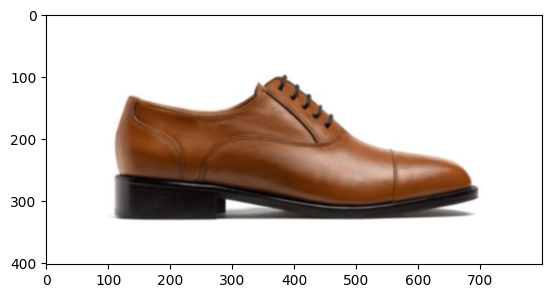

In [ ]:
import cv2

img = cv2.imread("data/ejemplo.jpg")

blur = cv2.GaussianBlur(img, (5,5), 0) # el cero es sigma -> como es cero se calcula con formula 

import matplotlib.pyplot as plt

plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))

> El papel que desempeña sigma es clave. Cuanto más grande, más se aplana la campana. Más valores se necesitan para rellenar el kernel. Es decir, los pixeles vecinos pesan casi igual que el central. Por tanto hay más desenfoque resultante en la imagen al aplicar el kernel sobre ella. 

## FILTRO LAPLACIANO

Detecta donde las zonas cambian rápidamente de intensidad, es decir, bordes. El gaussiano promedia valores-> desenfoque. El laplaciano es un operador de segundo orden -> calcula derivadas de derivadas o lo que es lo mismo, calcula una derivada de segundo orden = TASA DE CAMBIO DE INTENSIDAD. Es sensible a los contornos, que está guay para lo que sirve , pero...

> Evidentemente también es sensible a irregularidades y al ruido-> por eso en la práctica se aplica un Gaussiano y luego un Laplaciano. La segunda derivada amplifica cualquier variación brusca LAPLACIAN OF GAUSSIAN

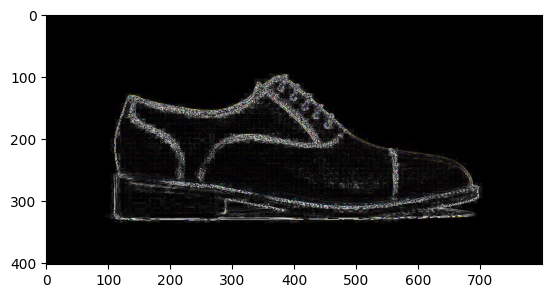

In [8]:
lap = cv2.Laplacian(img, cv2.CV_64F, ksize=3)

import numpy as np

plt.imshow(np.uint8(np.absolute(lap)), cmap='gray') # YA NO ESTA EN COLOR-> son bordes esta en gris

### OPERADOR CANNY

No es un fitlro, sirve para detectar bordes de manera completa-> algoritmo de varios pasos combinando varias técnicas. Pasos internos al hacer Canny():

1. Suavizado Gaussiano —> igual que vimos antes, quita ruido antes de calcular derivadas para bordes
2. Cálculo de gradientes —> calcula la derivada en X y en Y (similar a Sobel), obteniendo para cada píxel: magnitud (¿cuán fuerte es el cambio?) y dirección (¿hacia dónde apunta el borde?).
3. Supresión de no-máximos —> esto es lo que hace que los bordes salgan finos (1 píxel de ancho). Para cada píxel, mira en la dirección del gradiente: si hay un vecino con magnitud mayor, este píxel se descarta (se pone a 0), aunque tenga magnitud alta. Solo sobrevive el "pico" local.
4. Umbralización con histéresis —> aquí entran los dos números que pasas a cv2.Canny(img, umbral1, umbral2).

- Magnitud > umbral2 (el alto) → borde seguro, se acepta.
- Magnitud < umbral1 (el bajo) → no es borde, se descarta.
- Magnitud entre umbral1 y umbral2 → depende: se acepta solo si está conectado a un píxel ya aceptado como borde seguro.

> Esto es la "histéresis": un borde débil aislado se descarta (probablemente ruido), pero un borde débil que es continuación de un borde fuerte se conserva — así los bordes salen como líneas continuas, no como trazos punteados que se cortan donde el contraste baja un poco.

>  Combina en un solo paso lo que antes hacíamos por separado (Gaussiano + derivadas tipo Laplaciano/Sobel) y añade dos mejoras (adelgazar bordes + histéresis) que ni el Gaussiano ni el Laplaciano hacen por su cuenta.

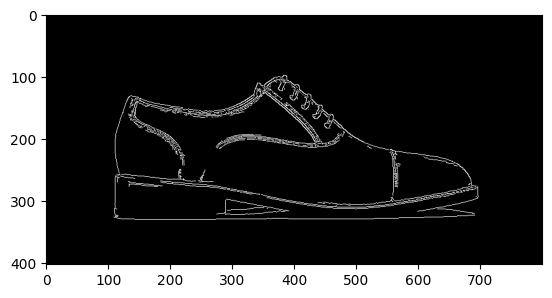

In [16]:
canny = cv2.Canny(img, 100,200) # si los bajas mas bordes. si los subes solo los mas claros

plt.imshow(canny, cmap='gray')

In [ ]:
np.unique(canny) # vemos como es binaria

array([  0, 255], dtype=uint8)

Las conclusiones son claras. Los filtros que hemos visto son una muestra de lo que ocurre realmente en una CNN. No osbtante, en una CNN los primeros filtros que se aprenden suelen ser muy parecido a los clásicos de Sobel o Prewitt, Laplaciano, etc... La red por su cuenta descubre que detectar bordes es útil para entender una imagen (lo sabemos pero la red lo redescubre)

La diferencia es que, mientras en OpenCV definimos los valores del kernel manualmente, en una CNN se aprenden automáticamente durante el entrenamiento-> son pesos que se aprenden por gradient descent y NO SON FIJOS. 

> CASO DE USO: teniendo pocos datos puede ser una buena opción aplicar un filtro de los que hemos visto, antes de meterlo en la CNN, le quitas trabajo. Pérdida de información: el Laplaciano se queda solo con "dónde cambia la intensidad" — descarta color, textura, intensidad absoluta. Para tejido sano/dañado, puede que la coloración (un tinte histológico, por ejemplo) sea diagnósticamente relevante, no solo los contornos. Si aplicas Laplaciano como paso obligatorio, esa información ya no está disponible — ni para ti ni para la red. Con datos suficientes, la red probablemente lo hace mejor sola: si tienes un dataset grande, una CNN entrenada de cero normalmente aprende filtros de borde adaptados a la tarea concreta (qué tipo de borde, qué orientaciones, qué escala importan para este problema) — mejor que un Laplaciano genérico que detecta "todos los bordes por igual".

> "Estos filtros también tienen un valor pedagógico... interpretabilidad"

OpenCV se integra con deep learning de dos formas

(1) como motor de pre/post-procesamiento (resize, realces, morphologyEx para limpiar máscaras), que es lo que ya usas en tu pipeline, y 

(2) como runtime ligero de inferencia (cv2.dnn) para entornos sin frameworks completos, útil sobre todo en edge/IoT. El patrón cargar→blob→forward→postprocesar es el mismo patrón que cualquier servicio de inferencia.